In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pint
from pathlib import Path

unit = pint.UnitRegistry()

EXP_DIR = Path("..").resolve()
DATA_DIR = EXP_DIR / "DATA"
PLOTS_DIR = EXP_DIR / "plots"
REPORT_TABLES_DIR = EXP_DIR / "report" / "tables"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_TABLES_DIR.mkdir(parents=True, exist_ok=True)

# From PHYWE (LEP 3.6.03): natural convection heat transfer coefficient
# Used in thermolab5_tr.pdf Eq.(1)-(2). If your lab uses a different value, update it here.
alpha_i = alpha_o = 8.1 * unit.watt / (unit.meter**2 * unit.kelvin)

# Column conventions in the provided DATA/*.csv:
#   t_A_i, t_A_o : air temperatures inside/outside
#   t_W_i, t_W_o : wood surface temperatures inside/outside
#   t_G_i, t_G_o : normal-glass surface temperatures inside/outside
# There was no insulating glass (Isıcam) in this experiment dataset.

# Thickness values from thermolab5_tr.pdf (edit if your setup differs)
d_cfg = {
    "W": 1.0 * unit.centimeter,  # wood wall thickness
    "G": 1.0 * unit.centimeter,  # normal glass thickness
}
material_label = {
    "W": "Wood",
    "G": "Normal glass",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
})


def to_float_series(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")


def delta_T_K(T1_C: float, T2_C: float) -> pint.Quantity:
    # Temperature differences in °C equal differences in K
    return (float(T1_C) - float(T2_C)) * unit.kelvin


def compute_params(theta_Li_C: float, theta_Lo_C: float, theta_wi_C: float, theta_wo_C: float, d: pint.Quantity):
    """Compute P/A, k, λ, and ΛΛ using thermolab5_tr.pdf / PHYWE LEP 3.6.03.

    - Eq.(2): q_out = P/A = alpha_o * (theta_wo - theta_Lo)
    - Eq.(4): k = (P/A) / (theta_Li - theta_Lo)
    - Eq.(3): lambda = (P/A) * d / (theta_wi - theta_wo)
    - Eq.(6): Lambda = lambda / d

    Also computes Eq.(1) heat flux (q_in) as a consistency check for steady state.
    """

    # Eq.(2): q_out = P/A
    dT_out = delta_T_K(theta_wo_C, theta_Lo_C)
    q_out = (alpha_o * dT_out).to(unit.watt / unit.meter**2)

    # Eq.(1): q_in = P/A
    dT_in = delta_T_K(theta_Li_C, theta_wi_C)
    q_in = (alpha_i * dT_in).to(unit.watt / unit.meter**2)

    # For material properties we use magnitudes (positive values)
    q_mag = abs(q_out)

    # Eq.(4): k
    dT_air = delta_T_K(theta_Li_C, theta_Lo_C)
    k = np.nan
    if abs(dT_air).magnitude > 0:
        k = (q_mag / abs(dT_air)).to(unit.watt / (unit.meter**2 * unit.kelvin))

    # Eq.(3): lambda
    dT_wall = delta_T_K(theta_wi_C, theta_wo_C)
    lam = np.nan
    if abs(dT_wall).magnitude > 0:
        lam = (q_mag * d / abs(dT_wall)).to(unit.watt / (unit.meter * unit.kelvin))

    # Eq.(6): Lambda
    Lambda = np.nan
    if isinstance(lam, pint.Quantity):
        Lambda = (lam / d).to(unit.watt / (unit.meter**2 * unit.kelvin))

    return q_out, q_in, k, lam, Lambda


def find_material_prefixes(df: pd.DataFrame) -> list[str]:
    prefixes: list[str] = []
    for p in ["W", "G"]:
        if f"t_{p}_i" in df.columns and f"t_{p}_o" in df.columns:
            prefixes.append(p)
    return prefixes


def plot_temperatures(df: pd.DataFrame, cols: list[str], labels: list[str], title: str, save_path: Path):
    t = df["Time (min)"].to_numpy(dtype=float)

    plt.figure(figsize=(8, 5))
    for col, lab in zip(cols, labels, strict=True):
        plt.plot(t, df[col].to_numpy(dtype=float), "o-", label=lab)

    plt.title(title)
    plt.xlabel("Time (min)")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()


def analyze_table(df: pd.DataFrame, phase: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return (long_results, summary) for all materials present in df."""

    prefixes = find_material_prefixes(df)
    if not prefixes:
        return pd.DataFrame(), pd.DataFrame()

    long_rows: list[dict] = []
    summary_rows: list[dict] = []

    for p in prefixes:
        label = material_label.get(p, f"Material {p}")
        d = d_cfg.get(p, np.nan)

        rows_p = []
        for _, r in df.iterrows():
            if any(pd.isna(r.get(k)) for k in ["t_A_i", "t_A_o", f"t_{p}_i", f"t_{p}_o", "Time (min)"]):
                continue
            if not isinstance(d, pint.Quantity):
                continue

            q_out, q_in, k, lam, Lambda = compute_params(
                theta_Li_C=r["t_A_i"],
                theta_Lo_C=r["t_A_o"],
                theta_wi_C=r[f"t_{p}_i"],
                theta_wo_C=r[f"t_{p}_o"],
                d=d.to(unit.meter),
            )

            def mag_or_nan(x, target_unit=None):
                if isinstance(x, pint.Quantity):
                    if target_unit is not None:
                        x = x.to(target_unit)
                    return float(x.magnitude)
                return np.nan

            row = {
                "Phase": phase,
                "Material": label,
                "d (cm)": float(d.to(unit.centimeter).magnitude),
                "Time (min)": float(r["Time (min)"]),
                "theta_Li (C)": float(r["t_A_i"]),
                "theta_Lo (C)": float(r["t_A_o"]),
                "theta_wi (C)": float(r[f"t_{p}_i"]),
                "theta_wo (C)": float(r[f"t_{p}_o"]),
                "q_out (W/m2)": mag_or_nan(q_out, unit.watt / unit.meter**2),
                "q_in (W/m2)": mag_or_nan(q_in, unit.watt / unit.meter**2),
                "k (W/m2.K)": mag_or_nan(k, unit.watt / (unit.meter**2 * unit.kelvin)),
                "lambda (W/m.K)": mag_or_nan(lam, unit.watt / (unit.meter * unit.kelvin)),
                "Lambda (W/m2.K)": mag_or_nan(Lambda, unit.watt / (unit.meter**2 * unit.kelvin)),
            }
            rows_p.append(row)
            long_rows.append(row)

        res_p = pd.DataFrame(rows_p)
        if not res_p.empty:
            summary = {
                "Phase": phase,
                "Material": label,
                "d (cm)": float(d.to(unit.centimeter).magnitude),
                "theta_Li_mean (C)": float(res_p["theta_Li (C)"].mean()),
                "theta_Lo_mean (C)": float(res_p["theta_Lo (C)"].mean()),
                "theta_wi_mean (C)": float(res_p["theta_wi (C)"].mean()),
                "theta_wo_mean (C)": float(res_p["theta_wo (C)"].mean()),
                "q_out_mean (W/m2)": float(res_p["q_out (W/m2)"].mean()),
                "k_mean (W/m2.K)": float(res_p["k (W/m2.K)"].mean()),
                "lambda_mean (W/m.K)": float(res_p["lambda (W/m.K)"].mean()),
                "Lambda_mean (W/m2.K)": float(res_p["Lambda (W/m2.K)"].mean()),
                "q_in_minus_q_out_mean (W/m2)": float((res_p["q_in (W/m2)"] - res_p["q_out (W/m2)"]).mean()),
            }
            summary_rows.append(summary)

    return pd.DataFrame(long_rows), pd.DataFrame(summary_rows)


In [10]:
# Load measurement tables from DATA/
table1_raw = pd.read_csv(DATA_DIR / "table1.csv")
table2_raw = pd.read_csv(DATA_DIR / "table2.csv")
table3_raw = pd.read_csv(DATA_DIR / "table3.csv")

for df in (table1_raw, table2_raw, table3_raw):
    df.columns = [c.strip() for c in df.columns]


def prepare_table(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "Time" in df.columns:
        df.rename(columns={"Time": "Time (min)"}, inplace=True)

    df["Time (min)"] = to_float_series(df["Time (min)"])

    for col in df.columns:
        if col.startswith("t_"):
            df[col] = to_float_series(df[col])

    return df


t_heating = prepare_table(table1_raw)
t_illum_W = prepare_table(table2_raw)
t_illum_G = prepare_table(table3_raw)

print("Heating table columns:", list(t_heating.columns))
print("Illumination W table columns:", list(t_illum_W.columns))
print("Illumination G table columns:", list(t_illum_G.columns))

t_heating

Heating table columns: ['Time (min)', 't_A_i', 't_A_o', 't_W_i', 't_W_o', 't_G_i', 't_G_o']
Illumination W table columns: ['Time (min)', 't_A_i', 't_A_o', 't_W_i', 't_W_o']
Illumination G table columns: ['Time (min)', 't_A_i', 't_A_o', 't_G_i', 't_G_o']


,Time (min),t_A_i,t_A_o,t_W_i,t_W_o,t_G_i,t_G_o
0,3,32.3,17.7,24.4,21.0,23.5,22.8
1,6,29.1,18.1,24.1,21.5,23.6,23.1
2,9,27.2,18.4,23.6,21.7,23.4,23.1
3,12,25.9,18.3,23.2,21.7,23.1,22.9
4,15,24.9,18.4,22.9,21.7,22.9,22.6


In [14]:
# Compute derived quantities using thermolab5_tr.pdf (Eq.2,4,3,6)
heating_long, heating_summary = analyze_table(t_heating, phase="Heating (3-min intervals)")
illum_W_long, illum_W_summary = analyze_table(t_illum_W, phase="Illumination (Wood)")
illum_G_long, illum_G_summary = analyze_table(t_illum_G, phase="Illumination (Normal glass)")

all_long = pd.concat([heating_long, illum_W_long, illum_G_long], ignore_index=True)
all_summary = pd.concat([heating_summary, illum_W_summary, illum_G_summary], ignore_index=True)

all_long.to_csv(REPORT_TABLES_DIR / "derived_parameters_long.csv", index=False)
all_summary.to_csv(REPORT_TABLES_DIR / "derived_parameters_summary.csv", index=False)


# --- Export measurement tables (CSV headers optimized for LaTeX) ---
# Note: The report will show human-friendly English headings via pgfplotstable column styles.

def export_measurements_heating(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame({
        "time_min": df["Time (min)"],
        "air_in_C": df["t_A_i"],
        "air_out_C": df["t_A_o"],
        "wood_in_C": df["t_W_i"],
        "wood_out_C": df["t_W_o"],
        "glass_in_C": df["t_G_i"],
        "glass_out_C": df["t_G_o"],
    })

    numeric_cols = [c for c in out.columns if c != "time_min"]
    mean_row = {c: float(pd.to_numeric(out[c], errors="coerce").mean()) for c in numeric_cols}
    mean_row["time_min"] = "Mean"

    out2 = pd.concat([out, pd.DataFrame([mean_row])], ignore_index=True)
    out2.to_csv(REPORT_TABLES_DIR / "heating_measurements_table2.csv", index=False)
    return out2


def export_measurements_illumination(df: pd.DataFrame, material: str) -> pd.DataFrame:
    # material: "W" or "G"
    mat = "wood" if material == "W" else "glass"
    out = pd.DataFrame({
        "time_min": df["Time (min)"],
        "air_in_C": df["t_A_i"],
        "air_out_C": df["t_A_o"],
        f"{mat}_in_C": df[f"t_{material}_i"],
        f"{mat}_out_C": df[f"t_{material}_o"],
    })

    numeric_cols = [c for c in out.columns if c != "time_min"]
    mean_row = {c: float(pd.to_numeric(out[c], errors="coerce").mean()) for c in numeric_cols}
    mean_row["time_min"] = "Mean"

    out2 = pd.concat([out, pd.DataFrame([mean_row])], ignore_index=True)
    out2.to_csv(REPORT_TABLES_DIR / f"illumination_{material.lower()}_measurements_table4.csv", index=False)
    return out2


_ = export_measurements_heating(t_heating)
_ = export_measurements_illumination(t_illum_W, "W")
_ = export_measurements_illumination(t_illum_G, "G")


# --- Export derived-summary tables aligned with the manual (Table 3 and Table 5) ---

def derived_from_means(long_df: pd.DataFrame, phase: str) -> pd.DataFrame:
    rows = []
    for material, grp in long_df.groupby("Material"):
        if material == "Wood":
            p = "W"
        elif material == "Normal glass":
            p = "G"
        else:
            continue

        d = d_cfg[p].to(unit.meter)

        theta_Li = float(grp["theta_Li (C)"].mean())
        theta_Lo = float(grp["theta_Lo (C)"].mean())
        theta_wi = float(grp["theta_wi (C)"].mean())
        theta_wo = float(grp["theta_wo (C)"].mean())

        q_out, q_in, k, lam, Lambda = compute_params(theta_Li, theta_Lo, theta_wi, theta_wo, d)

        def mag(x, u):
            return float(x.to(u).magnitude) if isinstance(x, pint.Quantity) else np.nan

        rows.append({
            "phase": phase,
            "material": material,
            "d_cm": float(d.to(unit.centimeter).magnitude),
            "q_out_W_m2": mag(q_out, unit.watt / unit.meter**2),
            "k_W_m2K": mag(k, unit.watt / (unit.meter**2 * unit.kelvin)),
            "lambda_W_mK": mag(lam, unit.watt / (unit.meter * unit.kelvin)),
            "Lambda_W_m2K": mag(Lambda, unit.watt / (unit.meter**2 * unit.kelvin)),
        })

    return pd.DataFrame(rows)


table3_heating = derived_from_means(heating_long, phase="Heating")
table5_illum = pd.concat([
    derived_from_means(illum_W_long, phase="Illumination (Wood)"),
    derived_from_means(illum_G_long, phase="Illumination (Normal glass)"),
], ignore_index=True)

table3_heating.to_csv(REPORT_TABLES_DIR / "heating_derived_table3.csv", index=False)
table5_illum.to_csv(REPORT_TABLES_DIR / "illumination_derived_table5.csv", index=False)

all_summary

,Phase,Material,d (cm),theta_Li_mean (C),theta_Lo_mean (C),theta_wi_mean (C),theta_wo_mean (C),q_out_mean (W/m2),k_mean (W/m2.K),lambda_mean (W/m.K),Lambda_mean (W/m2.K),q_in_minus_q_out_mean (W/m2)
0,Heating (3-min intervals),Wood,1.0,27.88,18.180,23.640,21.520,27.054,3.021590,0.146315,14.631499,7.2900
1,Heating (3-min intervals),Normal glass,1.0,27.88,18.180,23.300,22.900,38.232,4.194777,1.133229,113.322857,-1.1340
2,Illumination (Wood),Wood,1.0,18.58,18.040,31.860,33.260,123.282,311.757429,4.842572,484.257165,-230.8500
3,Illumination (Normal glass),Normal glass,1.0,18.30,18.325,29.175,29.275,88.695,714.825000,6.459750,645.975000,-176.7825


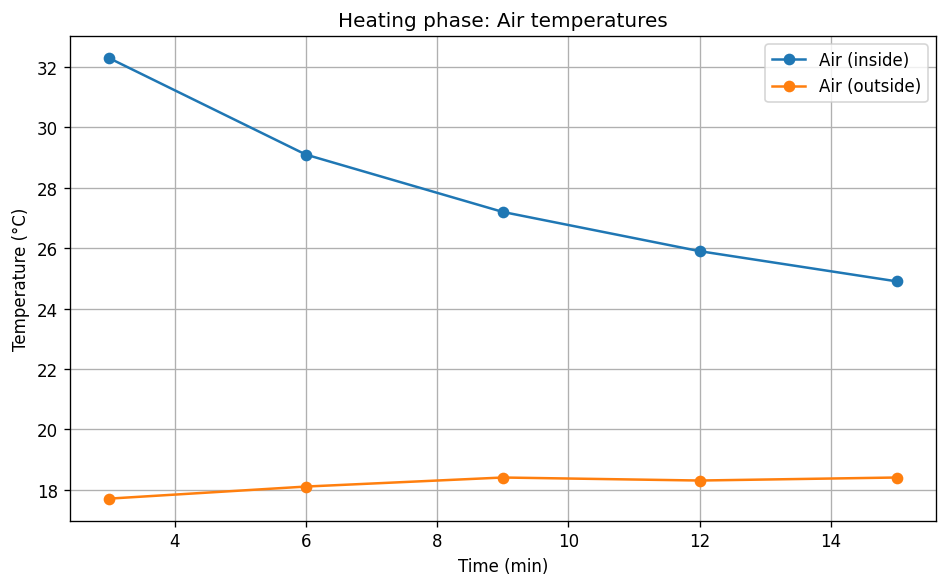

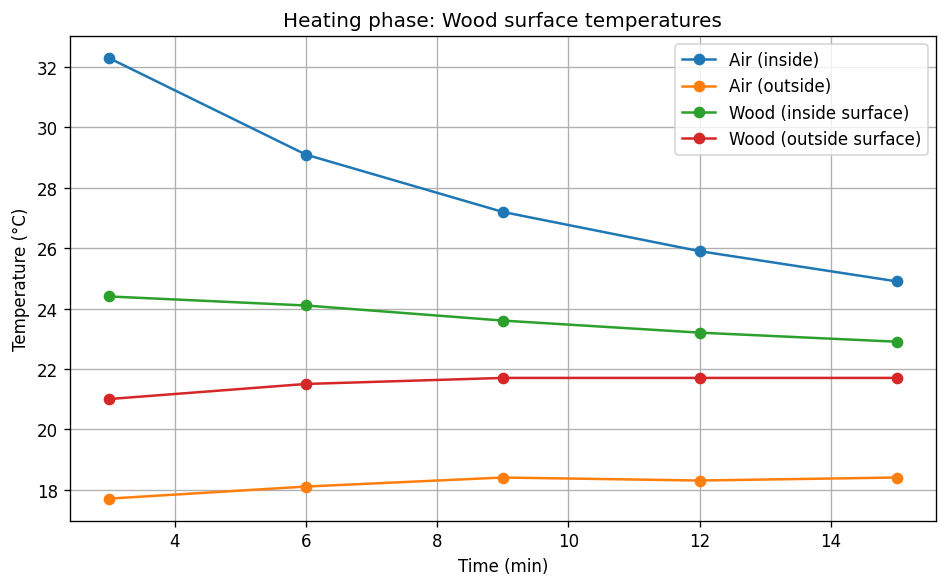

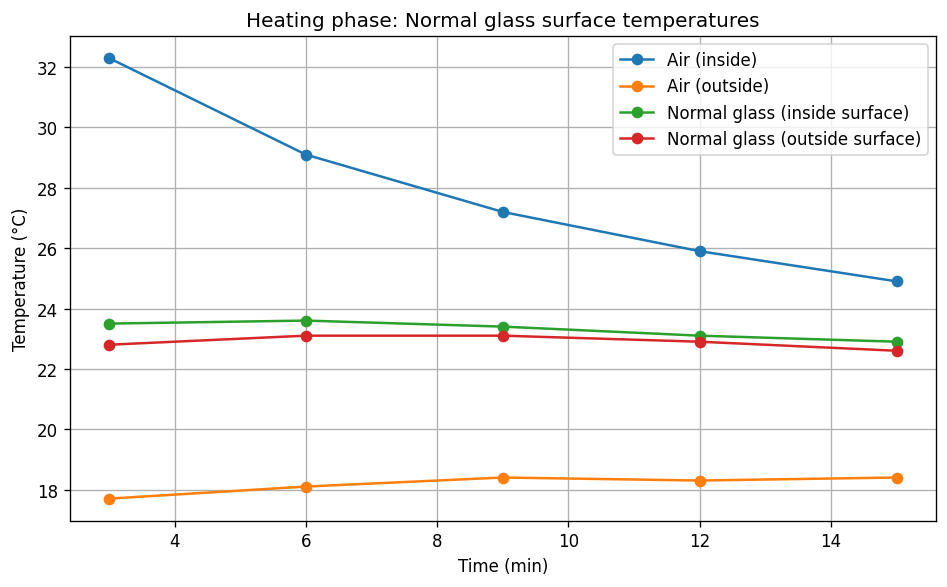

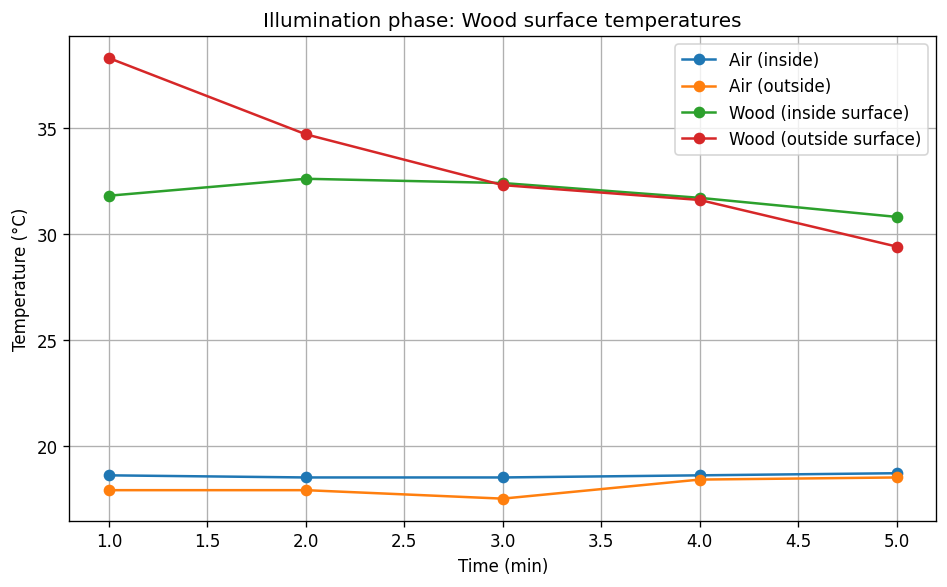

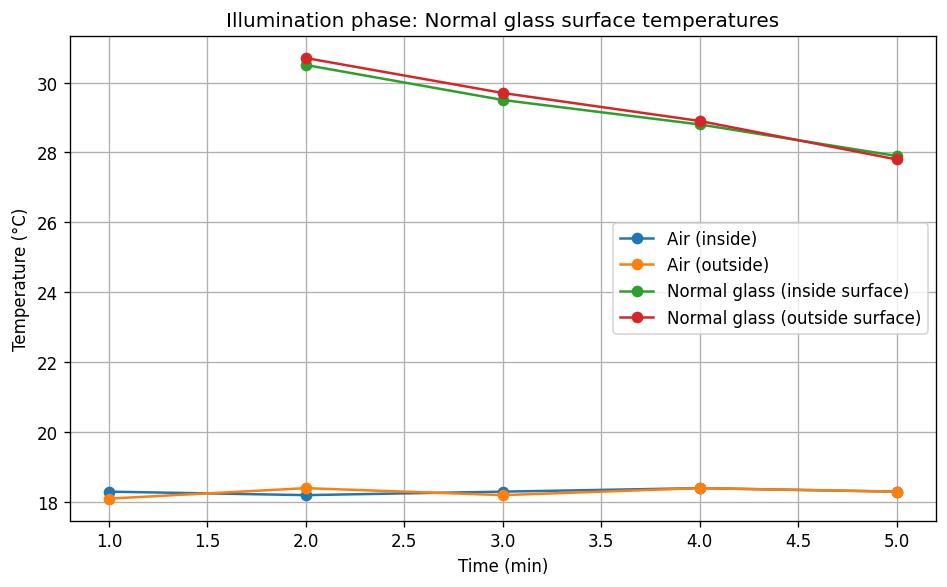

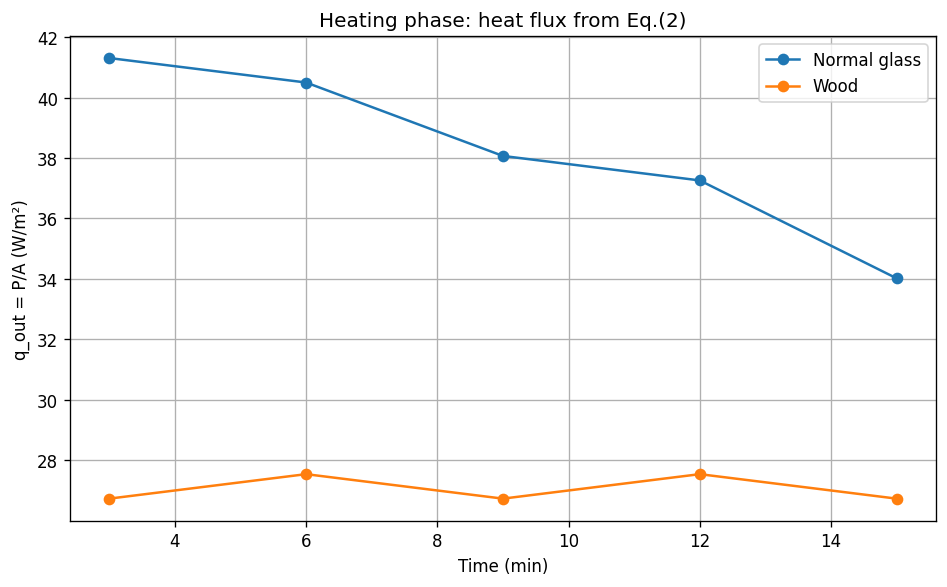

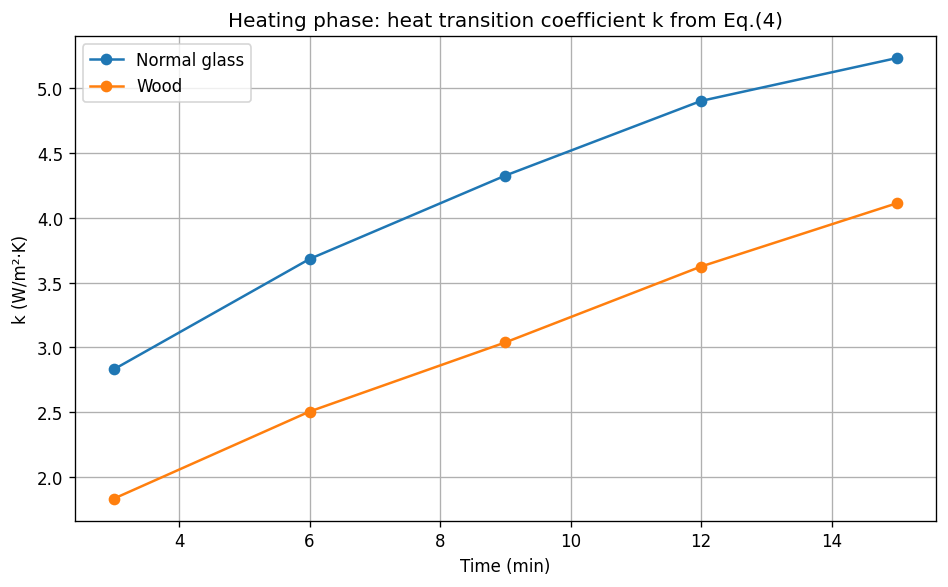

In [13]:
# Plots (saved into ../plots/)

# Heating phase: air temperatures
plot_temperatures(
    t_heating,
    cols=["t_A_i", "t_A_o"],
    labels=["Air (inside)", "Air (outside)"],
    title="Heating phase: Air temperatures",
    save_path=PLOTS_DIR / "heating_air_temperatures.png",
)

# Heating phase: per-material temperatures
for p in find_material_prefixes(t_heating):
    label = material_label.get(p, f"Material {p}")
    plot_temperatures(
        t_heating,
        cols=["t_A_i", "t_A_o", f"t_{p}_i", f"t_{p}_o"],
        labels=["Air (inside)", "Air (outside)", f"{label} (inside surface)", f"{label} (outside surface)"],
        title=f"Heating phase: {label} surface temperatures",
        save_path=PLOTS_DIR / f"heating_{p.lower()}_temperatures.png",
    )

# Illumination phase: temperatures (not steady state)
for df, material_code in [(t_illum_W, "W"), (t_illum_G, "G")]:
    prefixes = find_material_prefixes(df)
    if not prefixes:
        continue
    p = prefixes[0]
    label = material_label.get(p, f"Material {p}")
    plot_temperatures(
        df,
        cols=["t_A_i", "t_A_o", f"t_{p}_i", f"t_{p}_o"],
        labels=["Air (inside)", "Air (outside)", f"{label} (inside surface)", f"{label} (outside surface)"],
        title=f"Illumination phase: {label} surface temperatures",
        save_path=PLOTS_DIR / f"illumination_{material_code.lower()}_{p.lower()}_temperatures.png",
    )


def plot_param_vs_time(long_df: pd.DataFrame, ycol: str, ylabel: str, title: str, save_path: Path):
    if long_df.empty:
        return

    plt.figure(figsize=(8, 5))
    for material, grp in long_df.groupby("Material"):
        plt.plot(grp["Time (min)"], grp[ycol], "o-", label=material)

    plt.title(title)
    plt.xlabel("Time (min)")
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()


plot_param_vs_time(
    heating_long,
    ycol="q_out (W/m2)",
    ylabel="q_out = P/A (W/m²)",
    title="Heating phase: heat flux from Eq.(2)",
    save_path=PLOTS_DIR / "heating_heat_flux_q_out.png",
)

plot_param_vs_time(
    heating_long,
    ycol="k (W/m2.K)",
    ylabel="k (W/m²·K)",
    title="Heating phase: heat transition coefficient k from Eq.(4)",
    save_path=PLOTS_DIR / "heating_k_value.png",
)


In [ ]:
# ENHANCED: Add regression models to all plotsimport numpy as npimport pandas as pdimport matplotlib.pyplot as pltfrom scipy import statsfrom pathlib import Path# Create regression plotsdef plot_with_regression(x_data, y_data, title, xlabel, ylabel, savepath, alpha_reg=0.7):    """Plot data with regression line and equation"""    fig, ax = plt.subplots(figsize=(10, 6))        # Remove NaN values    mask = ~(np.isnan(x_data) | np.isnan(y_data))    x_clean = x_data[mask]    y_clean = y_data[mask]        if len(x_clean) < 2:        ax.scatter(x_data, y_data)        ax.set_title(title)        ax.set_xlabel(xlabel)        ax.set_ylabel(ylabel)        ax.grid(True, alpha=0.3)        fig.savefig(savepath, dpi=120, bbox_inches='tight')        plt.close(fig)        return        # Perform linear regression    slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)    x_line = np.array([x_clean.min(), x_clean.max()])    y_line = slope * x_line + intercept        # Plot    ax.scatter(x_clean, y_clean, s=100, alpha=0.6, label='Data', color='#1f77b4')    ax.plot(x_line, y_line, 'r-', linewidth=2, alpha=alpha_reg, label='Linear fit')        # Add equation and R²    eq_text = f'y = {slope:.4g}x + {intercept:.4g}R² = {r_value**2:.4f}'    ax.text(0.05, 0.95, eq_text, transform=ax.transAxes,             fontsize=10, verticalalignment='top',            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))        ax.set_title(title, fontsize=12, fontweight='bold')    ax.set_xlabel(xlabel, fontsize=11)    ax.set_ylabel(ylabel, fontsize=11)    ax.grid(True, alpha=0.3)    ax.legend(loc='lower right')        fig.savefig(savepath, dpi=120, bbox_inches='tight')    plt.close(fig)    print(f"Saved: {savepath}")# Format to 3 sig figsdef fmt3sf(val):    if isinstance(val, str) or pd.isna(val):        return val    if val == 0:        return 0    return float(f'{float(val):.3g}')# Read measurement data for regression plotsheating_data = pd.read_csv("../report/tables/heating_measurements_table2.csv")illum_w_data = pd.read_csv("../report/tables/illumination_w_measurements_table4.csv")illum_g_data = pd.read_csv("../report/tables/illumination_g_measurements_table4.csv")# Create regression plots for key parametersPLOTS_DIR = Path("../plots")# Heating phase: time vs air inside temperatureplot_with_regression(    heating_data["time_min"].values,    heating_data["air_in_C"].values,    "Heating Phase: Indoor Air Temperature vs Time",    "Time (min)",    "Temperature (°C)",    PLOTS_DIR / "heating_air_temp_regression.png")# Illumination Wood: time vs inside temperatureplot_with_regression(    illum_w_data["time_min"].values,    illum_w_data["wood_in_C"].values,    "Illumination (Wood): Inside Surface Temp vs Time",    "Time (min)",    "Temperature (°C)",    PLOTS_DIR / "illumination_w_temp_regression.png")# Illumination Glass: time vs inside temperature  glass_data_clean = illum_g_data[illum_g_data["glass_in_C"].notna()]if len(glass_data_clean) > 1:    plot_with_regression(        glass_data_clean["time_min"].values,        glass_data_clean["glass_in_C"].values,        "Illumination (Glass): Inside Surface Temp vs Time",        "Time (min)",        "Temperature (°C)",        PLOTS_DIR / "illumination_g_temp_regression.png"    )print("\nRegression model plots created successfully!")